<a href="https://colab.research.google.com/github/muraleee/collab-stuff/blob/main/notebooks/1.0-intro-langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install -U langchain-core langchain-openai

In [17]:
import os
import getpass

from google.colab import userdata



def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = userdata.get(var)

_set_env("OPENAI_API_KEY")
_set_env("ANTHROPIC_API_KEY")
_set_env("TAVILY_API_KEY")

In [ ]:
# option 1 with specific API provider Objects (ChatOpenAI, ChatAnthropic, ChatOllama....)
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

llm.invoke("HI!")

In [ ]:
# RECOMMENDED: Use this method to initialize the LLM
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "gpt-4o-mini",
    model_provider="openai")

model.invoke("Hi what is your model name?")

In [ ]:
# model = init_chat_model("claude-sonnet-4-5-20250929", model_provider="anthropic")

# model.invoke("Hi what is your name? Like the model name?")

# Full LLM App in LangChain

In [ ]:
import getpass
import os

try:
    # load environment variables from .env file (requires `python-dotenv`)
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

os.environ["LANGSMITH_TRACING"] = "true"
if "LANGSMITH_API_KEY" not in os.environ:
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass(
        prompt="Enter your LangSmith API key (optional): "
    )
if "LANGSMITH_PROJECT" not in os.environ:
    os.environ["LANGSMITH_PROJECT"] = getpass.getpass(
        prompt='Enter your LangSmith Project Name (default = "default"): '
    )
    if not os.environ.get("LANGSMITH_PROJECT"):
        os.environ["LANGSMITH_PROJECT"] = "default"
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass(
        prompt="Enter your OpenAI API key (required if using OpenAI): "
    )

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "gpt-5-mini",
    model_provider="openai"
)

model.invoke("Hi")

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage("Translate the following from English into Italian"),
    HumanMessage("Hi! Let's learn about large language models!"),
]

model.invoke(messages)

In [ ]:
model.invoke([{"role": "user", "content": "How are ya?"}])

In [ ]:
for token in model.stream("Tell me the 3 funniest jokes you know"):
    print(token.content, end="|")

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

system_template = "Translate the following from {language_source} into {language_target}"

prompt_template = ChatPromptTemplate.from_messages(
    [("system", system_template), ("human", "{input_sentence}")]
)

prompt_template.format(language_source="English", language_target="French", input_sentence="I love programming in Python")

In [ ]:
prompt = prompt_template.invoke({"language_source": "English", "language_target": "French", "input_sentence": "I love programming in Python"})
response = model.invoke(prompt) # calling the model
response

In [ ]:
response.content

In [ ]:
chain = prompt_template | model

response = chain.invoke({"language_source": "English", "language_target": "Italian", "input_sentence": "Lucas is a gorgeous bald teacher."})

In [ ]:
response.content

# Recap

Langchain gives you components:
- model access
- prompt templates to create reusable strings with dynamic variables
- chains: blocks of re-usable computation with LLMs + prompt templates

# Structured Outputs

In [ ]:
from pydantic import BaseModel, Field
from openai import OpenAI

class ElementsOfLiveCourse(BaseModel):
    title: str = Field(description="The title of the live course")
    topic: str = Field(description="The core topic of the live course")
    example_lesson: str = Field(description="An example lesson from the live course")

with open("./course_example.md", "r") as f:
    prompt_raw_course = f.read()

client = OpenAI()

response = client.beta.chat.completions.parse(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You take in raw information for a course and\
            you output the structured objects with information about that course"},
        {"role": "user", "content": prompt_raw_course}
    ],
    response_format=ElementsOfLiveCourse
)

response

In [ ]:
!pip install -U --force-reinstall langchain-core
!pip install -U langchain langchain-openai langchain-community

In [ ]:
# Reinstall langchain-openai and langchain-core to ensure compatible versions
# !pip install --upgrade --force-reinstall langchain-openai langchain-core

from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

# 1. Define your schema
class ElementsOfLiveCourse(BaseModel):
    title: str = Field(description="The title of the live course")
    topic: str = Field(description="The core topic of the live course")
    example_lesson: str = Field(description="An example lesson from the live course")

# 2. Load your data
# Ensure 'course_example.md' exists in your directory
with open("./course_example.md", "r") as f:
    prompt_raw_course = f.read()

# 3. Initialize the model
# Note: Ensure your OPENAI_API_KEY is set in your environment variables

llm = init_chat_model("gpt-5-mini", model_provider="openai")
# 4. Bind the structured output
structured_llm = llm.with_structured_output(ElementsOfLiveCourse)

# 5. Invoke and print
response = structured_llm.invoke(prompt_raw_course)

print(response)

In [10]:
response

ElementsOfLiveCourse(title='Introduction to AI and Large Language Models - Live Course', topic='Fundamentals of Artificial Intelligence and using Large Language Models', example_lesson='Lesson: Creating Simple Prompts with Python\n\nLearn how to interact with a language model by writing prompts in Python. You\'ll set up an API key, send a prompt, and read the model\'s response.\n\nExample:\n\n# Example using OpenAI\'s API (requires openai package)\nimport openai\n\nopenai.api_key = "YOUR_API_KEY"\n\nprompt = "What are three benefits of learning Artificial Intelligence?"\n\nresponse = openai.Completion.create(\n    engine="text-davinci-003",\n    prompt=prompt,\n    max_tokens=100\n)\n\nprint(response.choices[0].text.strip())\n\nExercise:\n- Change the prompt variable to ask your own question and observe how the model responds.')

In [11]:
from IPython.display import Markdown

str_output = f"""
# {response.title}

- *Topic*: {response.topic}

### Example Lesson

{response.example_lesson}
"""
Markdown(str_output)


# Introduction to AI and Large Language Models - Live Course

- *Topic*: Fundamentals of Artificial Intelligence and using Large Language Models

### Example Lesson

Lesson: Creating Simple Prompts with Python

Learn how to interact with a language model by writing prompts in Python. You'll set up an API key, send a prompt, and read the model's response.

Example:

# Example using OpenAI's API (requires openai package)
import openai

openai.api_key = "YOUR_API_KEY"

prompt = "What are three benefits of learning Artificial Intelligence?"

response = openai.Completion.create(
    engine="text-davinci-003",
    prompt=prompt,
    max_tokens=100
)

print(response.choices[0].text.strip())

Exercise:
- Change the prompt variable to ask your own question and observe how the model responds.


In [ ]:
llm = init_chat_model("gpt-5-mini", model_provider="openai")

llm.invoke("What are the elements of a Screenplay?")

## Pydantic Class

In [14]:
from typing import Optional
from pydantic import BaseModel, Field


# Pydantic
class ElementsOfScreenplay(BaseModel):
    """Elements of a Screenplay."""

    title: str = Field(description="The title of the screenplay")
    genre: str = Field(description="The genre of the screenplay")
    protagonist: str = Field(description="The protagonist of the screenplay")
    antagonist: str = Field(description="The antagonist of the screenplay")
    setting: str = Field(description="The setting of the screenplay")
    plot: str = Field(description="The plot of the screenplay")


structured_llm = llm.with_structured_output(ElementsOfScreenplay)

screenplay_structured = structured_llm.invoke("Structure a Screenplay about characters thinking about the meaninglessness of life.")

In [15]:
from IPython.display import Markdown

str_output = f"""
# {screenplay_structured.title}

- *Genre*: {screenplay_structured.genre}
- *Protagonist*: {screenplay_structured.protagonist}
- *Antagonist*
- *Setting*: {screenplay_structured.setting}

### Plot

{screenplay_structured.plot}
"""
Markdown(str_output)


# Echoes in Empty Rooms

- *Genre*: Existential Drama
- *Protagonist*: Maya — a 32-year-old schoolteacher wrestling with a creeping sense of purposelessness after a personal loss
- *Antagonist*
- *Setting*: A decaying coastal city in late autumn: cramped apartment buildings, a worn café that stays open late, a near-empty university auditorium, a hospital waiting room, and an empty pier where the wind carries voices out to sea

### Plot

Act I — Setup: We open on Maya lying awake in her narrow apartment, listening to the building's pipes, thinking about how small her life feels. A recent loss (the death of a close mentor or the end of a long relationship) leaves an absence she cannot name. She goes to work, teaches robotically, and notices a gap: students, colleagues, even the city routine feel hollow. The inciting incident is an argument with a coworker who calls Maya 'too sentimental' for believing in purpose; that night she meets Jonah, an old neighbor who bluntly says: “Life is just a sequence of events — stop pretending it’s a story.” This crystallizes her doubts.

Act II — Confrontation: Maya seeks answers in ordinary places. She converses with several foils: Jonah, who advocates quiet acceptance of the void; Lina, a young activist who constructs purpose through small, furious projects; and Dr. Patel, a retired philosopher who frames meaning as an ongoing practice rather than a fixed property of life. Each scene deepens the central question and pushes Maya toward extremes — from numbing routines to frantic attempts to manufacture significance (volunteer projects, public speeches, reckless intimacy). A midpoint scene strips away pretense: Maya delivers a failed talk in an empty auditorium and faces the echo of her own voice. The antagonistic force — the Void — shows its power through small erosions: missed paychecks, a funeral without comfort, students who shrug at earnest lessons.

Act II (continued) — The pressure mounts. Maya's attempts to impose meaning backfire or feel hollow; she alternates between anger and resignation. She has a climactic nighttime conversation with Jonah on the pier where he confesses his own fear of the void. This dissolves their easy stances and forces both to admit vulnerability. The city itself feels like a character: closed factories, changing faces, and rituals that have lost their edges. Maya begins to realize that the question of meaning isn't solved by answers but by choices about how to live in the face of absence.

Act III — Resolution: A crisis — perhaps a student's sudden act (leaving, a cry for help, or a small but consequential mistake) — demands immediate response. Maya can either retreat into nihilism or act. She chooses action that refuses grand answers but affirms connection: she stays with the student, organizes a small memorial ritual with the class, and quietly accepts that the ritual has no ultimate guarantee but still matters. The final scenes are modest: Maya reading to restless students, repairing a failed relationship with a sibling, and returning to the pier not to find meaning but to listen to the wind and the faint hum of the city.

Thematic arc and ending: The screenplay avoids neat resolutions. The antagonist — the Void — remains real and present, but the protagonist's arc moves from searching for a single salvific meaning to embracing the practice of giving partial, local meaning through care, attention, and small rituals. The final image: Maya and a small group standing at dawn on the pier, not triumphant but steady, choosing to act anyway. Key motifs: echoes, empty rooms, small rites, the sea as both eraser and witness. Tone: quiet, intimate, unsentimental, with moments of dark humor and tenderness.


# Model + Tools

In [18]:
from langchain_community.tools.tavily_search import TavilySearchResults

model = init_chat_model("gpt-5-mini", model_provider="openai")
search = TavilySearchResults(max_results=2)
tools = [search]

model_with_tools = model.bind_tools(tools)

output_model_tools = model_with_tools.invoke("What is the latest model released by Anthropic?")

In [ ]:
output_model_tools.tool_calls

The output we get here is something called a "tool call" which means, prepared arguments for a pre-defined function (in this case
web search with the tavily API) to gather the required information.

Now let's look at a full agent.

/tmp/ipython-input-51133970.py:12: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(model, tools, checkpointer=memory)


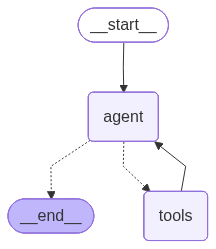

In [19]:
# Import relevant functionality
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# Create the agent
memory = MemorySaver()
model = init_chat_model("gpt-5-mini", model_provider="openai")
search = TavilySearchResults(max_results=2)
tools = [search]
agent_executor = create_react_agent(model, tools, checkpointer=memory)

agent_executor

Agent Executor is a graph!

In [20]:
# We pass config because this agent has memory so we need to pass a thread_id
config = {"configurable": {"thread_id": "abc123"}}
# Below we can't just invoke on "input" we use "messages" because the agent expects a list of messages (this info is hidden in the create_react_agent function)
agent_executor.invoke({"messages": [HumanMessage("What is the capital of Brazil?")]}, config=config)

{'messages': [HumanMessage(content='What is the capital of Brazil?', additional_kwargs={}, response_metadata={}, id='91ff836f-7cb1-44b2-9270-9ab97cea133b'),
  AIMessage(content='The capital of Brazil is Brasília. It has been the capital since 1960 (previously Rio de Janeiro) and is a purpose-built city in the Federal District.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 171, 'prompt_tokens': 167, 'total_tokens': 338, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D9ahECztoSWWbbzh9WnXRj0dGc9Jz', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c6275-5b9c-7272-86c1-4da7bb12f244-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

In [21]:
for step in agent_executor.stream(
    {"messages": [HumanMessage(content="What are the best LLM models right now according to artificialanalysis.ai")]},
    stream_mode="values",
    config=config
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What are the best LLM models right now according to artificialanalysis.ai
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_cnd4iCSFa8y2uVyQpT1bQh6B)
 Call ID: call_cnd4iCSFa8y2uVyQpT1bQh6B
  Args:
    query: artificialanalysis.ai best LLM models site:artificialanalysis.ai "best LLM" "artificialanalysis"
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Comparison of over 100 AI models from OpenAI, Google, DeepSeek ...", "url": "https://artificialanalysis.ai/leaderboards/models", "content": "Comparison and ranking the performance of over 100 AI models (LLMs) across key metrics including intelligence, price, performance and speed (output speed - tokens per second & latency - TTFT), context window & others. Intelligence: Claude Opus 4.6 (Adaptive) and  GP

In [ ]:
# !pip install langchain-ollama

from langchain.chat_models import init_chat_model

local_llm = init_chat_model("mistral-small3.2", model_provider="ollama")

local_llm.invoke("What are some predictions for AI in 2026?")

In [ ]:
search = TavilySearchResults(max_results=2)
tools = [search]
agent_executor = create_react_agent(local_llm, tools)

In [ ]:
agent_executor.invoke({"messages": [HumanMessage("What are some predictions for AI in 2026?")]})